In [4]:
import subprocess
subprocess.run(["pip","install","pandas","numpy","matplotlib","scikit-learn"])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'scikit-learn'], returncode=0)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(
    'Data\household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)

# Quick look
print(df.shape)
print(df.head())
print(df.dtypes)


<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\georg\AppData\Local\Temp\ipykernel_24324\519073183.py:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  'Data\household_power_consumption.txt',


(2075259, 9)
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  
Date                         str
Time                         str
Global_active_power 

In [6]:
# Combine Date and Time into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Set it as the index
df = df.set_index('datetime')

# Drop the now-redundant columns
df = df.drop(columns=['Date', 'Time'])

# Check missing values
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Total rows: 2075259


In [7]:
# Drop missing rows
df = df.dropna()

# Confirm
print(f"Rows after dropping nulls: {len(df)}")
print(f"Rows removed: {2075259 - len(df)}")

# Quick sanity check - look at our target column
print(f"\nGlobal Active Power stats:")
print(df['Global_active_power'].describe())

Rows after dropping nulls: 2049280
Rows removed: 25979

Global Active Power stats:
count    2.049280e+06
mean     1.091615e+00
std      1.057294e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.020000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64


In [8]:
# Resample from per-minute to per-hour (mean)
df_hourly = df['Global_active_power'].resample('h').mean()
df_hourly = df_hourly.to_frame()

print(df_hourly.shape)
print(df_hourly.head())

(34589, 1)
                     Global_active_power
datetime                                
2006-12-16 17:00:00             4.222889
2006-12-16 18:00:00             3.632200
2006-12-16 19:00:00             3.400233
2006-12-16 20:00:00             3.268567
2006-12-16 21:00:00             3.056467


In [9]:
# Extract time features
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['is_weekend'] = df_hourly['day_of_week'].isin([5, 6]).astype(int)

# Add lag features
df_hourly['lag_1h'] = df_hourly['Global_active_power'].shift(1)
df_hourly['lag_24h'] = df_hourly['Global_active_power'].shift(24)
df_hourly['lag_168h'] = df_hourly['Global_active_power'].shift(168)

# Drop nulls created by lag
df_hourly = df_hourly.dropna()

print(df_hourly.shape)
print(df_hourly.head())

(33418, 8)
                     Global_active_power  hour  day_of_week  month  \
datetime                                                             
2006-12-23 17:00:00             5.452533    17            5     12   
2006-12-23 18:00:00             3.879400    18            5     12   
2006-12-23 19:00:00             4.117833    19            5     12   
2006-12-23 20:00:00             4.181400    20            5     12   
2006-12-23 21:00:00             3.288433    21            5     12   

                     is_weekend    lag_1h   lag_24h  lag_168h  
datetime                                                       
2006-12-23 17:00:00           1  4.349100  1.496800  4.222889  
2006-12-23 18:00:00           1  5.452533  2.686967  3.632200  
2006-12-23 19:00:00           1  3.879400  3.938167  3.400233  
2006-12-23 20:00:00           1  4.117833  3.536067  3.268567  
2006-12-23 21:00:00           1  4.181400  4.548667  3.056467  


In [10]:
# Define features and target
X = df_hourly[['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h']]
y = df_hourly['Global_active_power']

# Split by time - first 80% for training, last 20% for testing
split_index = int(len(df_hourly) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print(f"Training ends: {X_train.index[-1]}")
print(f"Testing starts: {X_test.index[0]}")

Training rows: 26734
Testing rows: 6684
Training ends: 2010-01-29 11:00:00
Testing starts: 2010-01-29 12:00:00


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.3f} kW")

# Baseline comparison - what if we just predicted the mean?
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
print(f"Baseline MAE (always predict mean): {baseline_mae:.3f} kW")
print(f"Improvement over baseline: {((baseline_mae - mae) / baseline_mae * 100):.1f}%")

Mean Absolute Error: 0.347 kW
Baseline MAE (always predict mean): 0.638 kW
Improvement over baseline: 45.6%


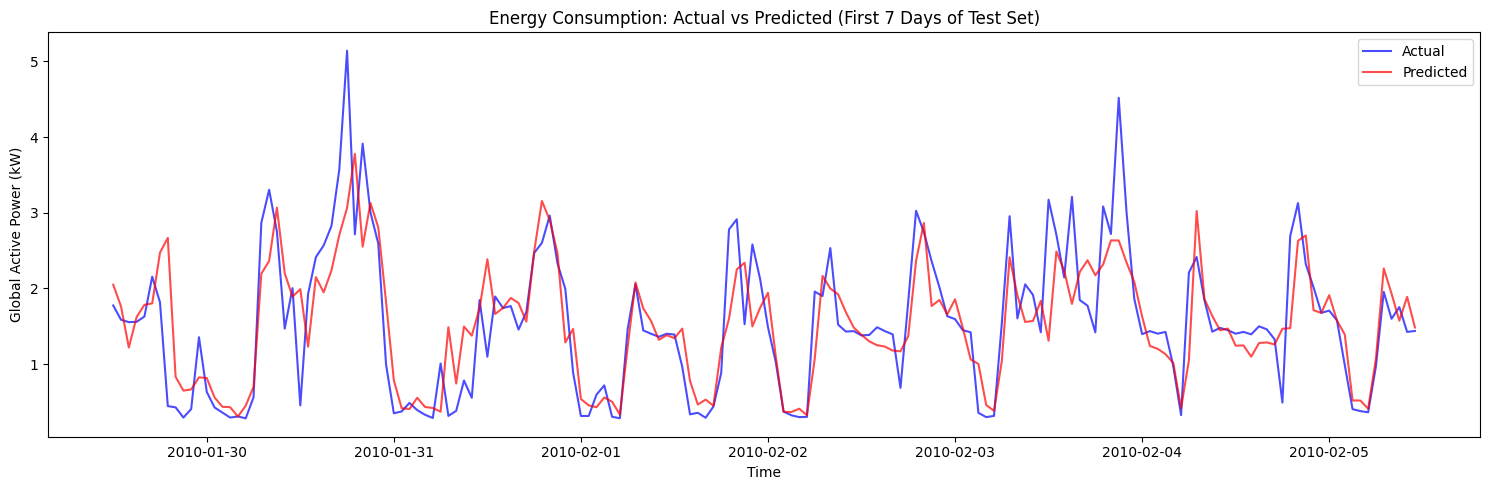

In [16]:
import matplotlib.pyplot as plt

# Plot predictions vs actual for first 7 days of test set
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:168], y_test.values[:168], label='Actual', color='blue', alpha=0.7)
plt.plot(y_test.index[:168], y_pred[:168], label='Predicted', color='red', alpha=0.7)
plt.title('Energy Consumption: Actual vs Predicted (First 7 Days of Test Set)')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('predictions_household.png', bbox_inches='tight', dpi=150)
plt.show()


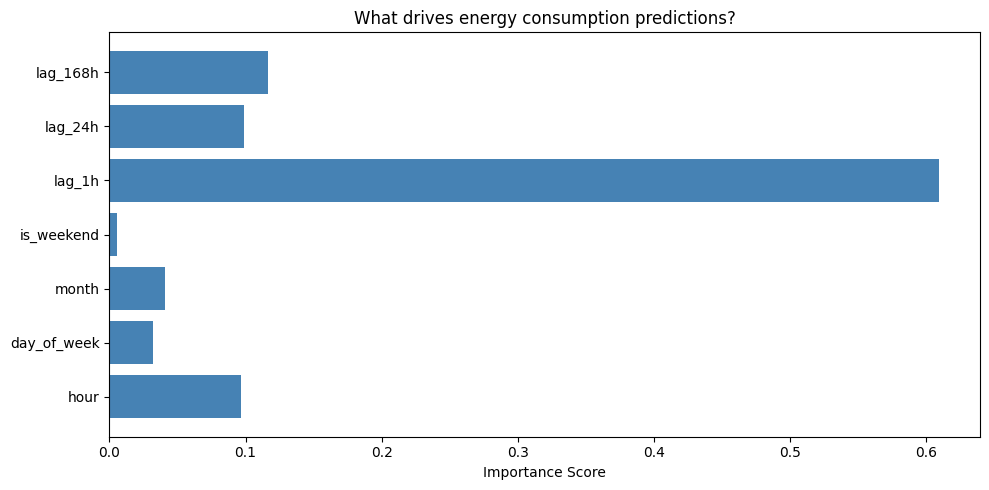

lag_1h: 0.609
lag_168h: 0.116
lag_24h: 0.099
hour: 0.097
month: 0.041
day_of_week: 0.032
is_weekend: 0.006


In [17]:
# Feature importance
features = ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h']
importances = model.feature_importances_

plt.figure(figsize=(10, 5))
plt.barh(features, importances, color='steelblue')
plt.xlabel('Importance Score')
plt.title('What drives energy consumption predictions?')
plt.tight_layout()
plt.savefig('feature_importance_household.png', bbox_inches='tight', dpi=150)
plt.show()

# Print the values too
for feature, importance in sorted(zip(features, importances), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {importance:.3f}")